# Movie Recommendation System

In [30]:
import pandas as pd

movies = pd.read_csv("ml-latest-small/movies.csv")
ratings = pd.read_csv("ml-latest-small/ratings.csv")

movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [31]:
ratings


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [32]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [33]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [34]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [35]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [36]:
movies['genres'] = movies['genres'].str.replace('|', ' ', regex=False)
movies['genres'] = movies['genres'].fillna('')

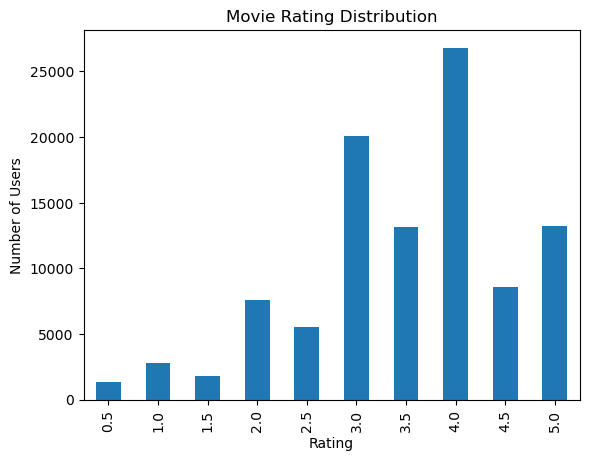

In [37]:
import matplotlib.pyplot as plt

ratings['rating'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Rating")
plt.ylabel("Number of Users")
plt.title("Movie Rating Distribution")
plt.show()

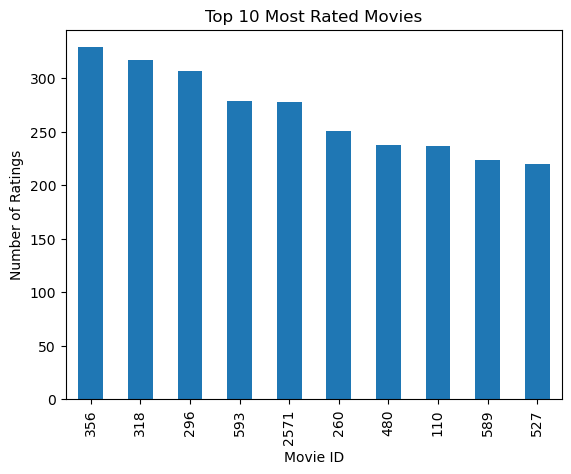

In [38]:
top_movies = ratings['movieId'].value_counts().head(10)
top_movies.plot(kind='bar')
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")
plt.title("Top 10 Most Rated Movies")
plt.show()

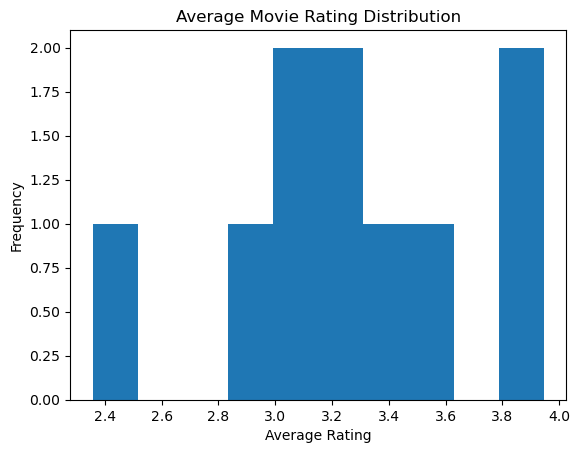

In [39]:
avg_rating = ratings.groupby('movieId')['rating'].mean()
avg_rating.head(10).plot(kind='hist')
plt.xlabel("Average Rating")
plt.title("Average Movie Rating Distribution")
plt.show()

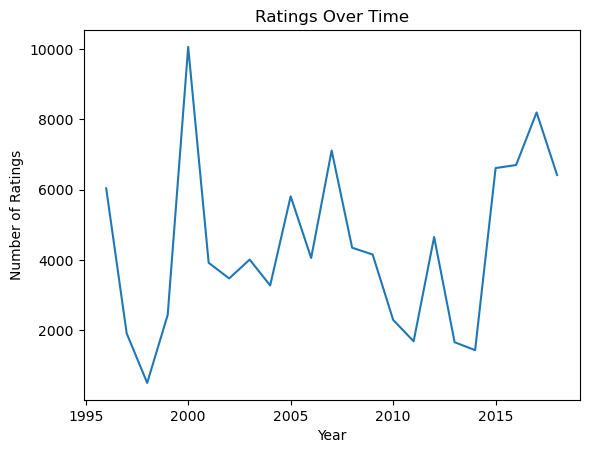

In [40]:
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings.groupby(ratings['timestamp'].dt.year)['rating'].count().plot()
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.title("Ratings Over Time")
plt.show()

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres'])

In [42]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23185 stored elements and shape (9742, 23)>

In [43]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [44]:
indices = pd.Series(movies.index, index=movies['title'])

In [45]:
def recommend_movie(title):
    idx = indices[title]
    scores = cosine_sim[idx]

    movie_scores = list(enumerate(scores))
    movie_scores = sorted(movie_scores, key=lambda x: x[1], reverse=True)

    movie_scores = movie_scores[1:6]   # skip same movie

    movie_indices = [i[0] for i in movie_scores]
    return movies['title'].iloc[movie_indices]


In [46]:
# def recommend_movie(title):
#     idx = indices[title]              # get movie index
#     scores = cosine_sim[idx]          # similarity scores
#     top_movies = scores.argsort()[-6:-1][::-1]
#     return movies['title'].iloc[top_movies]

In [47]:
recommend_movie("Toy Story (1995)")

1706                                       Antz (1998)
2355                                Toy Story 2 (1999)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
Name: title, dtype: object

In [48]:
recommend_movie("Flint (2017)")

25                     Othello (1995)
30             Dangerous Minds (1995)
36    Cry, the Beloved Country (1995)
39                 Restoration (1995)
50                     Georgia (1995)
Name: title, dtype: object

In [49]:
recommend_movie("Jobs (2013)")

25                     Othello (1995)
30             Dangerous Minds (1995)
36    Cry, the Beloved Country (1995)
39                 Restoration (1995)
50                     Georgia (1995)
Name: title, dtype: object

In [51]:
recommend_movie("Antz (1998)")

1706                                       Antz (1998)
2355                                Toy Story 2 (1999)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
Name: title, dtype: object